In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [8]:
data_dir = '/work/uo0122/u241387/SWOT_SSH/diags_2024/'
ds_segments = xr.open_dataset(data_dir+'swot_unsmoothed_aliased.nc')
ds_segments

<xarray.Dataset> Size: 681kB
Dimensions:                        (segment: 111, wavenumber: 250)
Coordinates:
  * segment                        (segment) int64 888B 0 1 2 3 ... 108 109 110
  * wavenumber                     (wavenumber) float64 2kB 0.0 0.001 ... 0.249
Data variables: (12/16)
    direct_psd                     (segment, wavenumber) float64 222kB ...
    aliased_psd                    (segment, wavenumber) float64 222kB ...
    total_psd                      (segment, wavenumber) float64 222kB ...
    lat_mean                       (segment) float64 888B ...
    lat_min                        (segment) float64 888B ...
    lat_max                        (segment) float64 888B ...
    ...                             ...
    n_pixels                       (segment) int64 888B ...
    valid_fraction                 (segment) float64 888B ...
    gap_filled                     (segment) bool 111B ...
    gap_fraction                   (segment) float64 888B ...
    swath                          (segment) <U5 2kB ...
    segment_index                  (segment) int64 888B ...

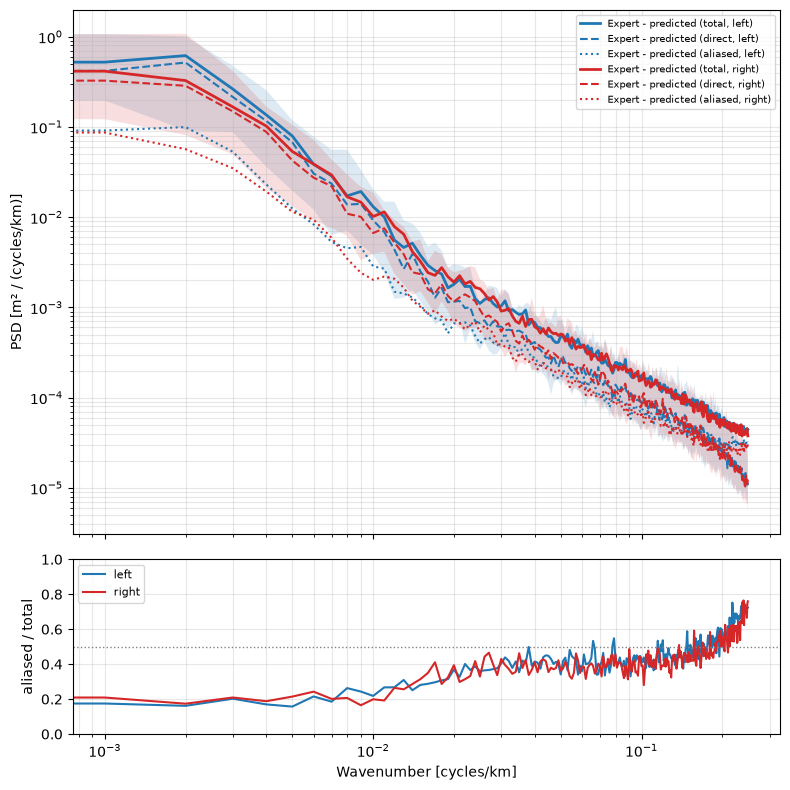

In [9]:
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                         gridspec_kw=dict(height_ratios=[3, 1]))

colors = {'left': 'C0', 'right': 'C3'}

for swath, c in colors.items():
    recs = ds_segments.where(ds_segments.swath==swath,drop=True)
    if not recs:
        continue
    k = recs['wavenumber'].values
    direct_stack = recs['direct_psd'].values
    aliased_stack = recs['aliased_psd'].values
    total_stack = direct_stack + aliased_stack
    
    direct_median = np.nanmedian(direct_stack, axis=0)
    direct_lo, direct_hi = np.nanpercentile(direct_stack, [25, 75], axis=0)
    aliased_median = np.nanmedian(aliased_stack, axis=0)
    aliased_lo, aliased_hi = np.nanpercentile(aliased_stack, [25, 75], axis=0)
    total_median = np.nanmedian(total_stack, axis=0)
    
    ax = axs[0]
    ax.fill_between(k, direct_lo, direct_hi, color=c, alpha=0.15, lw=0)
    ax.loglog(k, total_median, c=c, lw=2, label=f'Expert - predicted (total, {swath})')
    ax.loglog(k, direct_median, c=c, lw=1.5, ls='--', label=f'Expert - predicted (direct, {swath})')
    ax.loglog(k, aliased_median, c=c, lw=1.5, ls=':', label=f'Expert - predicted (aliased, {swath})')
    axs[1].semilogx(k, aliased_median / total_median, c=c, lw=1.5, label=swath)

axs[0].set_ylabel('PSD [m² / (cycles/km)]')
#axs[0].set_title(f'Patch-matched validation ({sum(len(v) for v in patch_match_results.values())} '
#                  f'matched patches, this file)')
axs[0].grid(True, which='both', alpha=0.3)
axs[0].legend(fontsize=7)

axs[1].axhline(0.5, c='0.5', ls=':', lw=1)
axs[1].set_ylabel('aliased / total')
axs[1].set_xlabel('Wavenumber [cycles/km]')
axs[1].grid(True, which='both', alpha=0.3)
axs[1].legend(fontsize=8)
axs[1].set_ylim(0.,1.0)
fig.tight_layout()